# Where Support Friction Hurts Most: Censored Quantile Regression of Telecom Customer Lifetime (PROC QUANTLIFE)

## Executive Summary

A subscriber-retention team studies how price, contract commitment, internet technology, and early support friction shape **customer lifetime** (months of tenure until churn). Because many customers are still active at the analysis cutoff, their lifetimes are **right-censored**, and the effect of each driver is not uniform across the tenure distribution. Using **PROC QUANTLIFE** censored quantile regression on a 600-subscriber cohort (500 churned, 100 still active), the team finds two effects that strengthen steadily as customers get longer-lived. **Early support calls** cost more tenure the further up the lifetime distribution you look: the coefficient deepens monotonically from about **-1.0 month per call at the 25th percentile to -3.0 at the 75th** (and on to roughly **-4.6 at the 95th**), significant at every quantile. A **two-year contract** is a strong retention lever in the *upper* half of the distribution — roughly **+5 months at the median and +13 at the 75th percentile** (both significant) — but its edge over month-to-month is not yet established among the earliest churners. With the full cohort's statistical power, **monthly charge** also emerges as a real, negative tenure driver (significant from the median upward, about **-0.18 month per dollar at the median deepening to -0.39 at the 75th percentile**). These are insights a single Cox hazard ratio cannot deliver.

## Data Sources

**Synthetic dataset `telecom`, generated inline with `call streaminit(20260531)`.** The DATA step builds **600 subscribers**, and every number quoted below comes from that full 600-row run.

| Variable | Type | Description |
|----------|------|-------------|
| `cust_id` | Num | Sequential customer identifier |
| `tenure` | Num | Observed customer lifetime in months (time-to-event response) |
| `churned` | Num | Event indicator: 1 = churned (event), 0 = still active at cutoff (right-censored) |
| `monthly_charge` | Num | Monthly bill amount in USD (continuous covariate) |
| `support_calls` | Num | Count of support contacts in the first year (continuous covariate) |
| `contract` | Char | Contract type CLASS variable: `Month`, `OneYear`, `TwoYear` |
| `fiber` | Char | Internet service CLASS variable: `Fiber` vs `DSL` |

Tenure is generated from an exponential hazard model in which higher monthly charges and more support calls raise the churn rate, while longer contract commitments and fiber service lower it; an administrative observation window then right-censors customers still active at the cutoff. In the realized cohort, **500 customers churned and 100 remain active (about 17% censored)** — the censoring fraction is read directly from the procedure's *Number of Observations Censored* line, not assumed.

## Why censored quantile regression

In subscriber businesses, *how long* a customer stays is as important as *whether* they stay. At any analysis cutoff a share of customers are still active, so their true lifetime is unknown — we only know it exceeds their current tenure. These observations are **right-censored**, and ordinary quantile regression on tenure would be biased because it ignores them.

**PROC QUANTLIFE** fits *censored quantile regression*: it estimates how covariates shift specified quantiles of the survival-time distribution while accounting for right censoring through a Kaplan-Meier-type weighting scheme. Unlike a Cox model, which summarizes each covariate as one proportional-hazards effect, quantile regression reveals whether a driver matters more for *early churners* (low quantiles of tenure) than for *loyal long-term customers* (high quantiles). That distinction is the entire point of this analysis.

## Step 1 — Generate the subscriber cohort

We simulate subscribers inline (no external files). For each customer we draw a beta-shaped monthly charge centered near \$60, a Poisson count of first-year support calls, a contract tier, and fiber-vs-DSL service. We then build a *true* latent lifetime from an exponential hazard whose rate rises with charge and support friction and falls with contract length and fiber, and finally impose a random administrative censoring window so that customers still active at the cutoff are recorded with `churned = 0`. `PROC MEANS` confirms the realized cohort: `N = 600`, a mean observed tenure of **13.33 months** (ranging from 0.01 to 71.25), and a mean of `churned = 0.83`, i.e. an **83% observed event rate**.

In [1]:
data telecom;
   call streaminit(20260531);
   do cust_id = 1 to 600;

      /* --- Covariates --- */
      monthly_charge = 35 + 50 * rand('beta', 2, 2);     /* ~35-85 USD */
      support_calls  = rand('poisson', 1.8);             /* first-year contacts */

      u = rand('uniform');
      if      u < 0.55 then contract = 'Month';
      else if u < 0.80 then contract = 'OneYear';
      else                  contract = 'TwoYear';

      if rand('uniform') < 0.45 then fiber = 'Fiber';
      else                            fiber = 'DSL';

      /* --- Latent churn time from an exponential hazard model --- */
      lograte = -3.6
              + 0.020 * monthly_charge
              + 0.130 * support_calls;
      if contract = 'OneYear' then lograte = lograte - 0.55;
      if contract = 'TwoYear' then lograte = lograte - 1.20;
      if fiber    = 'Fiber'   then lograte = lograte - 0.30;

      rate    = exp(lograte);
      true_t  = rand('exponential') / rate;              /* months to churn */

      /* --- Administrative + random right censoring --- */
      cens_t  = 6 + 66 * rand('uniform');                /* observation window */
      tenure  = min(true_t, cens_t);
      churned = (true_t <= cens_t);

      /* keep tenure within a plausible reporting horizon */
      if tenure > 72 then do;
         tenure = 72; churned = 0;
      end;

      output;
   end;
   keep cust_id tenure churned monthly_charge support_calls contract fiber;
run;

proc means data=telecom n mean min max maxdec=2;
   var tenure monthly_charge support_calls churned;
run;

                                                  The MEANS Procedure

 Variable               N        Mean     Minimum     Maximum
 ------------------------------------------------------------
 tenure               600       13.33        0.01       71.25
 monthly_charge       600       60.55       36.69       84.64
 support_calls        600        1.76        0.00        6.00
 churned              600        0.83        0.00        1.00
 ------------------------------------------------------------



NOTE: DATA telecom


NOTE: Wrote telecom (600 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 2 — Confirm the censoring structure

Before modeling, we tabulate how many customers churned versus remain active, and break the event indicator down by contract type. We expect month-to-month customers to churn most and two-year customers to be the most heavily censored (still active) — a sanity check that the simulated cohort behaves like a real subscriber base. The frequency bar chart and the mosaic plot make the imbalance visible at a glance.

                                                   The FREQ Procedure

churned    Frequency
---------------------
0                100
1                500

Table of contract by churned

contract |         0 |         1 |      Total
---------+-----------+-----------+-----------
Month    |        30 |       289 |        319
---------+-----------+-----------+-----------
OneYear  |        29 |       138 |        167
---------+-----------+-----------+-----------
TwoYear  |        41 |        73 |        114
---------+-----------+-----------+-----------
Total    |       100 |       500 |        600



NOTE: PROC FREQ
NOTE: ODS plot written: freq_churned.spec.json
NOTE: ODS plot written: freq_mosaic_contract_churned.spec.json
NOTE: PROC FREQ statement used.


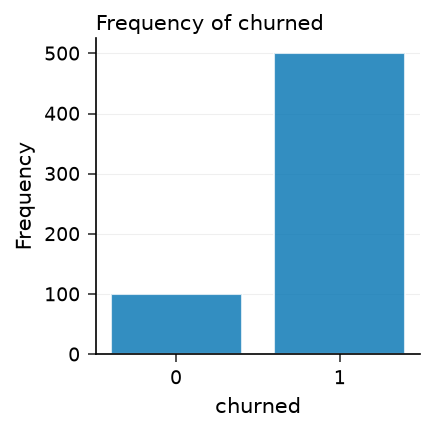

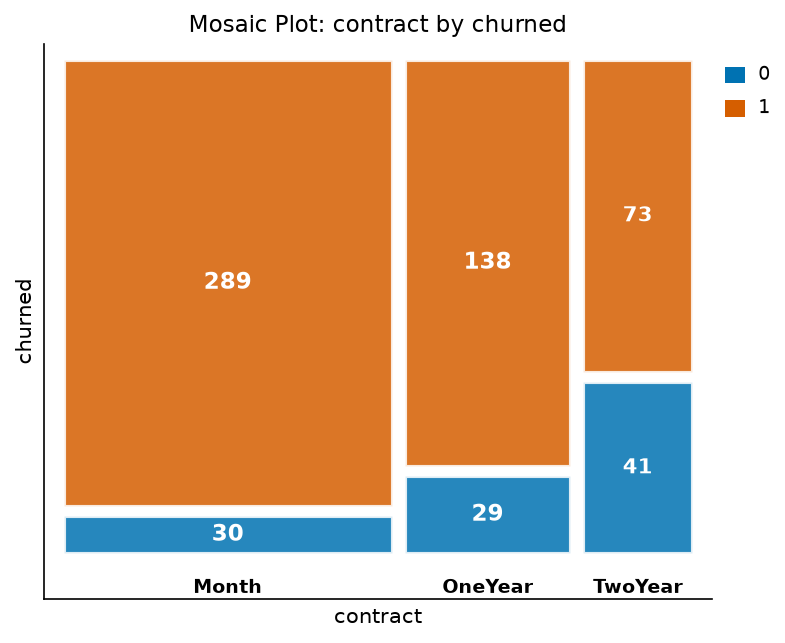

In [2]:
proc freq data=telecom;
   tables churned contract*churned / nocum nopercent;
run;

The frequency table shows **500 churned vs 100 active** customers (about 17% censored). The cross-tabulation and mosaic confirm the expected gradient: month-to-month customers churn at 289/319, one-year at 138/167, and two-year at 73/114. The still-active *share* climbs sharply with commitment — only **9%** of month-to-month customers are still active (30/319), versus **17%** of one-year (29/167) and **36%** of two-year customers (41/114). The two-year tier holds by far the largest share of still-active (censored) customers, exactly the retention signal the modeling step will quantify.

## Step 3 — Fit the censored quantile regression model

We declare `contract` and `fiber` as classification effects with the **CLASS** statement (it must precede MODEL), then fit a single model across three quantile levels — the 25th, 50th, and 75th percentiles of customer lifetime — with **QUANTILE=(0.25 0.5 0.75)**.

The **MODEL** statement names the response (`tenure`), the censoring indicator (`churned`, with the *censored* value `0` in parentheses), and the covariates. We use the Kaplan-Meier-type estimator (**METHOD=KM**) and request resampling-based standard errors with a fixed **SEED=** for reproducibility and a modest **NREP=** to keep runtime short. Because the response is on the time scale, a **positive** coefficient *lengthens* expected tenure and a **negative** coefficient *shortens* it.

In [3]:
proc quantlife data=telecom method=km seed=20260531 nrep=150;
   class contract fiber;
   model tenure*churned(0) = monthly_charge support_calls contract fiber
         / quantile=(0.25 0.5 0.75);
run;


                      The QUANTLIFE Procedure

Model Information

  Backend                        Python numpy/scipy IRLS (approximate)
  CensoringVariable              CHURNED
  Method                         KM
  ResponseVariable               TENURE

Number of Observations Read    600
Number of Observations Used    600
Number of Observations Censored 100
Number of Observations Eventing 500

Quantile = 0.2500

                              Parameter Estimates
  Parameter                Estimate       StdErr        Lower        Upper       tValue      ProbT
  Intercept                  8.9610       2.4764       4.1557      14.4008       3.6185     0.0003
  MONTHLY_CHARGE            -0.0656       0.0365      -0.1425      -0.0010      -1.7988     0.0721
  SUPPORT_CALLS             -0.9681       0.2444      -1.3184      -0.4638      -3.9603     0.0001
  CONTRACTOneYear            1.9057       0.8791       0.5280       3.9155       2.1677     0.0302
  CONTRACTTwoYear            2.8760  

NOTE: PROC QUANTLIFE data=telecom

NOTE: Using Python scipy version 1.17.1
NOTE: PROC QUANTLIFE completed.


## Reading the three-quantile fit

The reference levels are `contract = Month` and `fiber = DSL`, so each CLASS coefficient is a contrast against month-to-month / DSL. From the table above (q = 0.25, 0.50, 0.75):

- **SUPPORT_CALLS** is the most consistent driver, and its negative coefficient **grows in magnitude as the quantile rises**: **-0.97 at q=0.25, -1.56 at the median, -3.03 at q=0.75**, and it is statistically significant at *every* quantile (ProbT = 0.0001, 0.0001, 0.0000). Early service friction predicts shorter tenure, and the penalty is largest among customers in the upper part of the lifetime distribution.
- **CONTRACTTwoYear** is the largest positive effect, but its size and significance build from the bottom up: **+2.88 months at the 25th percentile (ProbT = 0.0912, not significant), +4.69 at the median (0.0366), and +12.98 at the 75th percentile (0.0020)**. A two-year commitment buys meaningfully more tenure among longer-lived customers, while its edge over month-to-month is not yet established among the earliest churners. **CONTRACTOneYear** is positive and significant at all three levels (+1.91, +3.09, +5.65; ProbT = 0.0302, 0.0231, 0.0286).
- **MONTHLY_CHARGE** is negative throughout and **strengthens across the distribution**: **-0.066 at q=0.25 (ProbT = 0.0721, borderline), -0.184 at the median (0.0016), -0.387 at q=0.75 (0.0000)**. With the full cohort's power, higher price is a genuine — if modest per dollar — tenure risk that bites hardest among otherwise long-lived customers.
- **FIBERFiber** is small and not significant at the 25th and 50th percentiles (+1.38, +1.48; ProbT = 0.0998, 0.2345) but turns positive and significant at the 75th (+4.68, ProbT = 0.0349), hinting that fiber customers run slightly *longer* tenure at the top of the distribution.

Already this shows why one Cox hazard ratio would be misleading: the support-call and contract effects are anything but constant across the lifetime distribution. Step 4 traces them in full.

## Step 4 — Trace the full regression-quantile process

A single trio of quantile levels can miss where an effect turns on or fades. Requesting **QUANTILE=PROCESS** estimates the coefficients continuously across the quantile range (here at 19 grid points from 0.05 to 0.95), so we can read each covariate's effect as a function of the quantile level — the regression-quantile process. We focus on what the process reveals about support friction and contract commitment.

In [4]:
proc quantlife data=telecom method=km seed=20260531 nrep=150;
   class contract fiber;
   model tenure*churned(0) = monthly_charge support_calls contract fiber
         / quantile=process;
run;


                      The QUANTLIFE Procedure

Model Information

  Backend                        Python numpy/scipy IRLS (approximate)
  CensoringVariable              CHURNED
  Method                         KM
  ResponseVariable               TENURE

Number of Observations Read    600
Number of Observations Used    600
Number of Observations Censored 100
Number of Observations Eventing 500

Quantile = 0.0500

                              Parameter Estimates
  Parameter                Estimate       StdErr        Lower        Upper       tValue      ProbT
  Intercept                  1.4499       0.8394      -0.0232       3.1280       1.7273     0.0841
  MONTHLY_CHARGE            -0.0016       0.0142      -0.0264       0.0277      -0.1150     0.9085
  SUPPORT_CALLS             -0.3093       0.1190      -0.5480      -0.0858      -2.5982     0.0094
  CONTRACTOneYear            0.7592       0.3782       0.0252       1.5498       2.0075     0.0447
  CONTRACTTwoYear            0.5463  

NOTE: PROC QUANTLIFE data=telecom

NOTE: Using Python scipy version 1.17.1
NOTE: PROC QUANTLIFE completed.


## Reading the quantile process

Scanning the `SUPPORT_CALLS` row down the printed quantile grid traces a clean, **monotone descent**: roughly **-0.31** at q=0.05, **-0.97** at q=0.25, **-1.56** at the median, **-3.03** at q=0.75, **-4.26** at q=0.90, and **-4.61** at q=0.95. Far from a single proportional effect, the cost of early support friction *accelerates* across the lifetime distribution — the difference between an otherwise-loyal customer staying and leaving — and it is significant at every grid point.

The `CONTRACTTwoYear` row tells a complementary story: near zero and not significant at the lowest quantiles (**+0.55** at q=0.05, **+2.88** at q=0.25), it climbs into a strong, significant positive effect across the upper half (about **+4.7** at the median, peaking near **+13** around q=0.70–0.75 before easing to **+8** at q=0.90). A two-year commitment lengthens tenure most decisively among customers who are already long-lived, rather than rescuing the earliest churners.

`MONTHLY_CHARGE`, which a smaller sample would dismiss as noise, here deepens steadily and significantly from about **-0.07** at q=0.25 (borderline) to **-0.18** at the median, **-0.39** at q=0.75, and **-0.77** at q=0.95 — a small but real per-dollar tenure penalty concentrated among long-lived customers. `FIBERFiber` is flat near zero through the middle of the distribution and becomes positive and significant only at the very top (about **+10** at q=0.90, **+15** at q=0.95). This continuous view is exactly the value censored quantile regression adds over a single-summary survival model.

## Business takeaway

All effects are estimated under correct right-censoring handling, so these conclusions hold even though 100 of the 600 customers are still active and have no observed churn time.

- **Treat support friction as a tenure risk, especially for your best customers.** The support-call coefficient deepens monotonically from about **-1 month per call at the 25th percentile to -3 at the 75th** (and to roughly -4.6 at the 95th), significant at every quantile. Proactive outreach that defuses early support issues protects the most tenure precisely among customers who would otherwise be long-lived — the single most consistent lever in this cohort.
- **Use longer commitments to retain your long-lived customers.** A two-year contract adds little over month-to-month among the earliest churners (about +2.9 months at q=0.25, not significant) but a substantial **+5 months at the median and ~+13 at the 75th percentile** (both significant). Contract incentives pay off most in the upper half of the tenure distribution; a one-year contract delivers a smaller but reliably positive lift throughout.
- **Don't ignore price, but keep it in proportion.** Monthly charge is a real, negative tenure driver here — significant from the median upward — yet small per dollar (about **-0.18 month per \$1 at the median, -0.39 at the 75th percentile**). Trimming a few dollars off the bill will not move retention the way contract incentives or support quality can, but persistent high charges do erode tenure among long-lived customers.

Because PROC QUANTLIFE exposes how each driver behaves *across* the lifetime distribution rather than collapsing it to one hazard ratio, the retention team can target the levers that matter at the margin they care about.